In [1]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torchvision.transforms import Compose
from torch.utils.data import DataLoader
import logging

logging.getLogger('matplotlib.image').setLevel(logging.ERROR)

In [2]:
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps' # MPS stands for the macOS Metal Programming Framework
print(f"using device: {device}")

using device: cuda


In [3]:
root = 'data'

In [4]:
train_transforms = Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
val_transforms = Compose([
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [5]:
train_dataset = CIFAR10(root=root, train=True, transform=train_transforms, download=True)
val_dataset = CIFAR10(root=root, train=False, transform=val_transforms, download=True)

100%|██████████| 170M/170M [35:10<00:00, 80.8kB/s]


In [6]:
"""num_workers > 0 activates multiprocessing, meaning that while the GPU trains the model on the current batch, the worker processes prepare the next batches on the CPU"""
train_loader = DataLoader(train_dataset, batch_size=128, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2, shuffle=False)

## [Iterate through the DataLoader in PyTorch](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#iterate-through-the-dataloader)

- We have loaded the dataset into the **DataLoader** and can iterate through the dataset as needed.

- Each iteration returns a batch of train_features and train_labels (containing **batch_size=128** features and labels respectively)

Feature shape: torch.Size([128, 3, 32, 32])
Specific image shape: torch.Size([3, 32, 32])


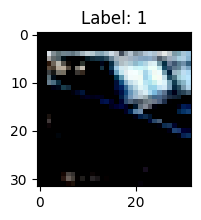

In [34]:
# Display the image and label
feature, label = next(iter(train_loader))
print(f"Feature shape: {feature.shape}")
print(f"Specific image shape: {feature[0].shape}") # Shape [3, 32, 32]

img = feature[0].permute(1, 2, 0) # Shape [32, 32, 3]
label = label[0]

plt.figure(figsize=(2, 2))
plt.title(f"Label: {label}")
plt.imshow(img)
plt.show()

## How do we calculate the CNNs output dimension?

**Key note:** Both stride and padding have **0** learnable parameters, because they are configuration parameters

- **stride & padding** control the dimension of the output (Wout X Hout), via the following formula:

In [8]:
"""
nn.Sequential is a subcalss of nn.Module designed to eliminate boilerplate code writing
It is a quick wrapper used when the data flows in a strictly linear, one-way manner.
The output of layer 1 becomes the input of layer 2...
Here's a simple example of model built using nn.Sequential:
"""

num_classes=10
model = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1),
    torch.nn.GELU(),
    torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1),
    torch.nn.GELU(),
    torch.nn.Flatten(), # 4D -> 2D
    torch.nn.Linear(in_features=64*28*28, out_features=num_classes)
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## What about counting a model's parameters?

To calculate the **total number of trainable parameters** in a deep learning model, you must evaluate each layer type based on its structural components (weights and biases).

---

#### 1. Convolutional Layer (Conv2D)
A **convolutional layer** performs spatial feature extraction. The parameters consist of the weights inside the moving kernels and one bias term per filter.

* **Formula:**
$$Parameters = (K_w \times K_h \times C_{in} + 1) \times C_{out}$$

* **Variables:**
    * $K_w, K_h$: Kernel width and height.
    * $C_{in}$: Number of input channels.
    * $C_{out}$: Number of output filters.
    * $+1$: Bias term per filter.

> **Note:** Hyperparameters like **Stride** and **Padding** alter the output feature map size, but they contain **0 parameters** and do not change the parameter count.

---

#### 2. Batch Normalization Layer (BatchNorm)
**Batch Normalization** standardizes the inputs to a layer. For every single channel, it tracks four specific parameters: two that are learned via backpropagation and two statistical moving averages.

* **Formula:**
$$Parameters = 4 \times C$$

* **Variables:**
    * $C$: Number of channels (or features) in the input tensor.
    * **Trainable Parameters (2 per channel):** Scale factor ($\gamma$) and Shift offset ($\beta$).
    * **Non-Trainable Parameters (2 per channel):** Moving Mean ($\mu$) and Moving Variance ($\sigma^2$).

---

#### 3. Fully Connected Layer (Dense / Linear)
Represented by the linear transformation equation $y = xA^T + b$. It connects every single input neuron to every single output neuron.

* **Formula:**
$$Parameters = (C_{in} \times C_{out}) + C_{out}$$

* **Variables:**
    * $C_{in}$: Number of input features/neurons.
    * $C_{out}$: Number of output features/neurons.
    * $C_{in} \times C_{out}$: Weight matrix size ($A$).
    * $C_{out}$: Bias vector size ($b$).

---

#### 4. Max / Average Pooling Layers
Pooling operations slide a window across the input spatial dimensions to reduce its resolution (downsampling).

* **Formula:**
$$Parameters = 0$$

* **Mechanism:** They possess no weights or biases. They strictly execute a fixed logical rule, choosing either the maximum value ($\max$) or the average value ($\text{mean}$) within the specified region.

---

#### 5. Activation Functions (ReLU, Sigmoid, GELU, etc.)
**Activation layers** introduce non-linearity into the network, mapping input values to output values element by element.

* **Formula:**
$$Parameters = 0$$

* **Mechanism:** They represent static mathematical transformations (e.g., $f(x) = \max(0, x)$ for ReLU). Operations are applied elementwise without any learning variables.

In [9]:
"""
Let's manually count the parameters of our model:

C1: (3 * 3 (kernel h & w) * 3 + 1) * 32 = 896
C2: (3 * 3 (kernel h & w) * 32 + 1) * 64 = 18,496
FC: (64 * 28 * 28) * 10 = 501,760
Total: 521,162 params

Obs: over 96% of model parameters are in FC, because the input is still large (28x28) when it gets to Flatten
"""

(sum(p.numel() for p in model.parameters()) == 521162)

True

In [10]:
epochs=60

In [11]:
model.to(device)
model = torch.compile(model)
train_loss_l = []
val_loss_l = []
crit = torch.nn.CrossEntropyLoss()

for epoch in range(epochs):

  if device == 'cuda':
    torch.cuda.synchronize() # Waits for the GPU residuals completing
  t0 = time.perf_counter()

  # Training Phase
  model.train()
  running_loss = 0.0

  for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = crit(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    if batch_idx % 100 == 0:
      print(f"epoch {epoch+1} || batch: {batch_idx:03d} || loss: {loss.item():.4f}")

  epoch_loss = running_loss / len(train_loader)
  train_loss_l.append(epoch_loss)

  # Validation Phase
  model.eval()

  correct = 0
  total = 0
  val_loss = 0.0

  with torch.no_grad():
    for val_images, val_labels in val_loader:
      val_images, val_labels = val_images.to(device), val_labels.to(device)

      val_outputs = model(val_images)
      loss = crit(val_outputs, val_labels)

      _, predicted = torch.max(val_outputs, 1) # dim 1 represents the logits

      total += val_labels.size(0)
      correct += (predicted == val_labels).sum().item()

      val_loss += loss.item()

  epoch_val_loss = val_loss / len(val_loader)
  val_accuracy = 100 * correct / total
  val_loss_l.append(epoch_val_loss)

  if device == 'cuda':
    torch.cuda.synchronize() # Waits for the GPU residuals completing
  t1 = time.perf_counter()

  epoch_duration = t1 - t0

  print(f"epoch {epoch+1} || train_loss {epoch_loss:.2f} || val_loss {epoch_val_loss:.2f} || val_accuracy {val_accuracy:.2f}% || time: {epoch_duration:.2f}s ")

W0831 19:22:11.194000 2032 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


epoch 1 || batch: 000 || loss: 2.3036
epoch 1 || batch: 100 || loss: 1.9310
epoch 1 || batch: 200 || loss: 1.7366
epoch 1 || batch: 300 || loss: 1.7135
epoch 1 || train_loss 1.74 || val_loss 1.52 || val_accuracy 45.97% || time: 35.75s 
epoch 2 || batch: 000 || loss: 1.5797
epoch 2 || batch: 100 || loss: 1.5165
epoch 2 || batch: 200 || loss: 1.7561
epoch 2 || batch: 300 || loss: 1.4420
epoch 2 || train_loss 1.56 || val_loss 1.37 || val_accuracy 51.05% || time: 19.92s 
epoch 3 || batch: 000 || loss: 1.4430
epoch 3 || batch: 100 || loss: 1.6954
epoch 3 || batch: 200 || loss: 1.4661
epoch 3 || batch: 300 || loss: 1.3487
epoch 3 || train_loss 1.49 || val_loss 1.35 || val_accuracy 52.01% || time: 21.16s 
epoch 4 || batch: 000 || loss: 1.5254
epoch 4 || batch: 100 || loss: 1.4727
epoch 4 || batch: 200 || loss: 1.5825
epoch 4 || batch: 300 || loss: 1.7263
epoch 4 || train_loss 1.44 || val_loss 1.31 || val_accuracy 54.25% || time: 20.52s 
epoch 5 || batch: 000 || loss: 1.4000
epoch 5 || batch: 

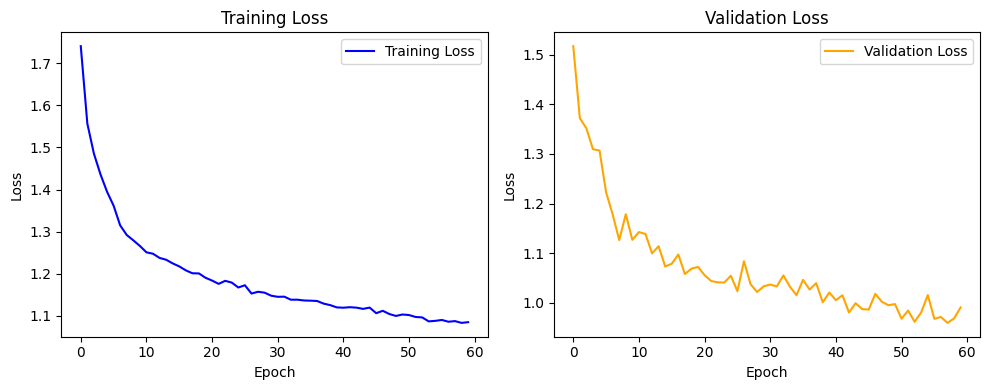

In [15]:
"""Let's now plot the training & validation losses"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(train_loss_l, label='Training Loss', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()

ax2.plot(val_loss_l, label='Validation Loss', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [32]:
"""Custom live inference script"""
import random

def test_visual_preds(model: torch.nn.Module | torch.nn.Sequential, test_loader: DataLoader, num_images: int = 5, save_plt: str | None = None, seed: int | None = None):
  model.eval()

  classes = [
      "airplane", "automobile", "bird", "cat", "deer",
      "dog", "frog", "horse", "ship", "truck"
  ]

  device = next(model.parameters()).device

  images, labels = next(iter(test_loader))

  if seed:
    random.seed(seed)

  random_indices = random.sample(range(len(images)), num_images)

  fig, axes = plt.subplots(1, num_images, figsize=(2*num_images, 4))

  if num_images == 1:
    axes = [axes] # ensures axes is always iterable

  with torch.no_grad():
    for i, idx in enumerate(random_indices):
      img = images[idx]
      label = labels[idx].item() # Get the true label as int

      img_batch = img.unsqueeze(0).to(device)

      outputs = model(img_batch)

      pred = torch.argmax(outputs, dim=1).item()

      true_name = classes[label]
      pred_name = classes[pred]

      axes[i].imshow(img.permute(1, 2, 0))

      color = 'green' if pred == label else 'red'

      if pred_name == true_name:
        axes[i].set_title(f"True: {true_name}\nPred: {pred_name}\nyay", color=color)
      else:
        axes[i].set_title(f"True: {true_name}\nPred: {pred_name}\n", color=color)
      axes[i].axis('off') # hides the axes for better visualization

    plt.tight_layout()

    if isinstance(save_plt, str):
      plt.savefig(save_plt, bbox_inches='tight')
    elif save_plt is True: # safety measure
      plt.savefig('visual_preds_output.png', bbox_inches='tight')

    plt.show()

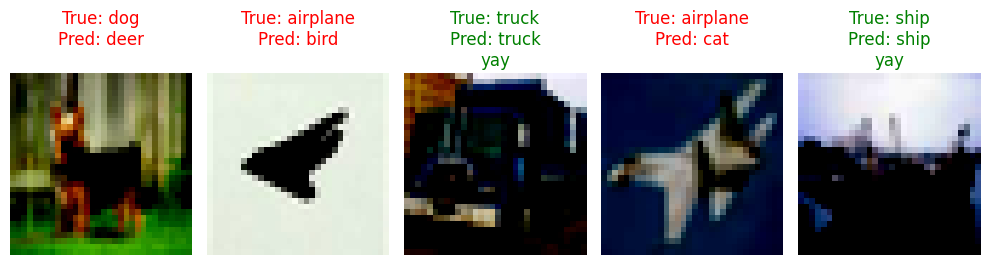

In [33]:
test_visual_preds(model, val_loader, num_images=5, save_plt="val_result.png", seed=41)